# HumanEvalComm V2 — Robust Benchmark Development

This notebook implements the comprehensive benchmarking framework for HumanEvalComm V2 as described in the development plan. It evaluates multiple LLM models on:

- Communication performance (asking clarifying questions)
- Code correctness (beyond Pass@1, include fuzzing)
- Trustworthiness (readability, maintainability, security, efficiency)
- Evaluation reliability (multi-judge + calibration)

## 1. Import Required Libraries

In [31]:
import os
import json
import asyncio
import time
from datetime import datetime
from typing import Dict, List, Optional, Any
from dataclasses import dataclass, asdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv
from tqdm import tqdm
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Load environment variables
load_dotenv()

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load HumanEvalComm Dataset

Load the HumanEvalComm dataset with multiple prompt variations for comprehensive benchmarking.

In [33]:
def load_dataset(dataset_path: str = "Benchmark/HumanEvalComm.jsonl", max_problems: int = -1) -> List[Dict]:
    """Load HumanEvalComm dataset with multiple prompt variations."""
    problems = []
    
    try:
        with open(dataset_path, 'r') as f:
            for i, line in enumerate(f):
                if max_problems > 0 and i >= max_problems:
                    break
                problems.append(json.loads(line.strip()))

        
        print(f"📚 Loaded {len(problems)} problems from {dataset_path}")
        return problems
    
    except FileNotFoundError:
        print(f"❌ Dataset file not found: {dataset_path}")
        return []
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return []

# Load the dataset
problems = load_dataset(max_problems=2)  # Start with 5 problems for testing

if not problems:
    print("❌ No problems loaded! Please check the dataset path.")
else:
    print("✅ Dataset loaded successfully")
    print(f"   Available prompt types: {[k for k in problems[0].keys() if k.startswith('prompt')]}")
    print(f"   Test cases per problem: {len(problems[0].get('test_case', []))}")

📚 Loaded 2 problems from Benchmark/HumanEvalComm.jsonl
✅ Dataset loaded successfully
   Available prompt types: ['prompt', 'prompt1a', 'prompt1c', 'prompt1p', 'prompt2ap']
   Test cases per problem: 7


## 3. Initialize HuggingFace Client

Set up the OpenAI client to work with HuggingFace's router service for model inference.

In [34]:
# Verify token is loaded
print("🔍 Checking token...")
hf_token = os.getenv("HF_TOKEN") or 'USE_YOUR_TOKEN'
if not hf_token:
    raise ValueError("❌ No HuggingFace API token found! Please set HF_TOKEN in your .env file")
print(f"✅ Token loaded (starts with: {hf_token[:10]}...)")

# Initialize OpenAI client with HuggingFace router
client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=hf_token,
)

print("✅ HuggingFace OpenAI client initialized")

# Example usage (as provided)
completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct:cerebras",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)

print("Example response:")
print(completion.choices[0].message.content)

🔍 Checking token...
✅ Token loaded (starts with: hf_aQwqsaO...)
✅ HuggingFace OpenAI client initialized


INFO:httpx:HTTP Request: POST https://router.huggingface.co/v1/chat/completions "HTTP/1.1 200 OK"


Example response:
The capital of France is Paris.


## 4. Define Model Configurations

Define the models to benchmark with their configurations.

In [35]:
@dataclass
class ModelConfig:
    """Configuration for a HuggingFace model using OpenAI wrapper."""
    name: str
    model_id: str  # Model ID for HuggingFace router
    max_tokens: int = 1024
    temperature: float = 0.1
    description: str = ""
    provider: str = ""  # Optional provider specification

# Define models to benchmark
models = {
    'llama3-8b': ModelConfig(
        name="Llama-3.1-8B-Instruct",
        model_id="meta-llama/Llama-3.1-8B-Instruct",
        description="Meta's Llama 3.1 8B instruction model",
        provider="cerebras"  # Fast inference provider
    ),
    # 'codellama-7b': ModelConfig(
    #     name="CodeLlama-7B-Instruct",
    #     model_id="meta-llama/CodeLlama-7b-Instruct-hf",
    #     description="Meta's CodeLlama 7B parameter instruction-tuned model"
    # ),
    # 'deepseek-coder': ModelConfig(
    #     name="DeepSeek-Coder-6.7B-Instruct",
    #     model_id="deepseek-ai/deepseek-coder-6.7b-instruct",
    #     description="DeepSeek's code generation model"
    # ),
    'Qwen2.5-Coder-32B-Instruct': ModelConfig(
        name="Qwen2.5-Coder-32B-Instruct",
        model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
        description="Qwen's 32B instruction model",
        provider="together"  # Fast inference provider
    ),
}

print("✅ Model configurations defined:")
for key, config in models.items():
    print(f"  - {key}: {config.name} ({config.description})")

✅ Model configurations defined:
  - llama3-8b: Llama-3.1-8B-Instruct (Meta's Llama 3.1 8B instruction model)
  - Qwen2.5-Coder-32B-Instruct: Qwen2.5-Coder-32B-Instruct (Qwen's 32B instruction model)


## 5. Load V2 Evaluators

Initialize the project's evaluators that will assess the quality of generated code.

In [36]:
# Add the project root to Python path
import sys
sys.path.append('.')

# Initialize evaluators
try:
    from evaluators import (
        AutomatedStaticDynamic,
        SandboxRunner,
        Aggregator,
        MultiLLMJudge,
        HFMultiLLMJudge
    )
    
    analyzer = AutomatedStaticDynamic()
    sandbox = SandboxRunner(use_docker=False)
    aggregator = Aggregator()
    
    print("✅ V2 Evaluators initialized:")
    print("  - AutomatedStaticDynamic: Static and dynamic code analysis")
    print("  - SandboxRunner: Safe code execution")
    print("  - Aggregator: Composite scoring and evaluation")
    
except ImportError as e:
    print(f"❌ Error importing evaluators: {e}")
    print("Please ensure you're running this notebook in the project's virtual environment")

✅ V2 Evaluators initialized:
  - AutomatedStaticDynamic: Static and dynamic code analysis
  - SandboxRunner: Safe code execution
  - Aggregator: Composite scoring and evaluation


## 6. Define Benchmark Data Structures

Create data structures to store benchmark results and evaluation metrics.

In [37]:
@dataclass
class EvaluationResult:
    """Results from evaluating a single problem with a model."""
    problem_id: str
    model_name: str
    prompt_type: str
    raw_response: str
    extracted_code: str
    is_question: bool
    
    # V2 Evaluator scores
    composite_score: float = 0.0
    test_pass_rate: float = 0.0
    static_analysis_score: float = 0.0
    security_score: float = 0.0
    
    # Communication metrics
    communication_rate: float = 0.0
    question_quality: float = 0.0
    
    # Execution metrics
    execution_success: bool = False
    execution_time: float = 0.0
    memory_usage: float = 0.0
    
    # Metadata
    timestamp: str = ""
    error_message: str = ""
    
    # Additional metrics
    cyclomatic_complexity: float = 0.0
    maintainability_index: float = 0.0
    pylint_score: float = 0.0
    bandit_issues_count: int = 0
    
def extract_code_from_response(response: str) -> str:
    """Extract code from model response."""
    import re
    
    # Look for code blocks
    code_pattern = re.compile(r'```(?:python)?\n?(.*?)\n?```',
                             re.DOTALL | re.IGNORECASE)
    matches = code_pattern.findall(response)
    
    if matches:
        return matches[0].strip()
    
    # If no code blocks, check if response is mostly code
    lines = response.strip().split('\n')
    code_lines = [line for line in lines
                 if line.strip().startswith(('def ', 'class ', 'import ',
                                           'from ', '    '))]
    
    if len(code_lines) > len(lines) * 0.5:  # More than 50% code lines
        return response.strip()
    
    return ""

def is_question(response: str) -> bool:
    """Check if response contains clarifying questions."""
    question_indicators = [
        '?', 'what', 'how', 'when', 'where', 'why', 'which', 'who',
        'could you', 'can you', 'please clarify', 'unclear', 'ambiguous',
        'need more', 'additional information', 'specify', 'clarification',
        'not clear', 'missing', 'incomplete'
    ]
    
    response_lower = response.lower()
    question_count = sum(1 for indicator in question_indicators
                       if indicator in response_lower)
    
    # Consider it a question if multiple indicators or explicit question marks
    return question_count >= 2 or '?' in response

def evaluate_questions(questions: str) -> float:
    """Simple heuristic evaluation of question quality."""
    question_count = questions.lower().count('?')
    relevant_keywords = ['clarify', 'unclear', 'ambiguous', 'specify', 'missing']
    keyword_count = sum(1 for keyword in relevant_keywords
                      if keyword in questions.lower())
    
    # Simple scoring: more questions and relevant keywords = higher quality
    return min(1.0, (question_count * 0.3 + keyword_count * 0.2))

def generate_test_code(problem: Dict, code: str) -> str:
    """Generate test code from problem test cases."""
    if 'test_case' not in problem:
        return ""

    entry_point = problem.get('entry_point', 'candidate')
    test_cases = problem['test_case']

    test_code = f"""
# Test code for {problem['name']}
{code}

def test_solution():
    \"\"\"Test the generated solution.\"\"\"
    try:
"""

    for i, test_case in enumerate(test_cases[:5]):  # Limit to 5 test cases
        input_val = test_case['input']
        expected = test_case['output']
        relation = test_case.get('relation', '==')

        if relation == '==':
            test_code += f"""
        # Test case {i+1}
        result_{i} = {entry_point}({input_val})
        assert result_{i} == {expected}, f"Test {{i+1}} failed: expected {expected}, got {{result_{i}}}"
"""

    test_code += """
        return True
    except Exception as e:
        print(f"Test failed: {e}")
        return False

if __name__ == "__main__":
    test_solution()
"""

    return test_code

## 7. Implement Model Inference Functions

Create functions to generate code using HuggingFace models and evaluate the responses.

In [38]:
async def generate_code(model_config: ModelConfig, prompt: str) -> Optional[str]:
    """Generate code using HuggingFace OpenAI wrapper."""
    try:
        # Construct model ID with provider if specified
        model_id = model_config.model_id
        if model_config.provider:
            model_id = f"{model_config.model_id}:{model_config.provider}"

        # Create the prompt message
        messages = [
            {
                "role": "system",
                "content": ("You are an expert software developer. "
                          "Generate Python code or ask clarifying questions "
                          "if the requirements are unclear.")
            },
            {
                "role": "user",
                "content": prompt
            }
        ]

        # Use asyncio to run the synchronous OpenAI call
        loop = asyncio.get_event_loop()
        completion = await loop.run_in_executor(
            None,
            lambda: client.chat.completions.create(
                model=model_id,
                messages=messages,
                max_tokens=model_config.max_tokens,
                temperature=model_config.temperature,
                timeout=60
            )
        )

        return completion.choices[0].message.content.strip()

    except Exception as e:
        print(f"   Error generating code: {e}")
        return None

async def evaluate_code_full(result: EvaluationResult, problem: Dict):
    """Evaluate generated code using V2 evaluators (full pipeline)."""
    try:
        # Create test code
        test_code = generate_test_code(problem, result.extracted_code)

        # Run static and dynamic analysis
        static_results, dynamic_results = analyzer.analyze_code(
            result.extracted_code, test_code, result.problem_id
        )

        # Run in sandbox
        execution_result = sandbox.run_code(result.extracted_code, test_code)

        # Update result with execution metrics
        result.execution_success = execution_result.success
        result.execution_time = execution_result.execution_time
        result.memory_usage = execution_result.memory_used

        # Aggregate results
        evaluation = aggregator.evaluate_problem(
            problem_id=result.problem_id,
            test_results=dynamic_results,
            static_results=static_results,
            sandbox_results=execution_result
        )

        # Update result with scores
        result.composite_score = evaluation.composite_score
        result.test_pass_rate = evaluation.test_pass_rate_score
        result.static_analysis_score = evaluation.static_analysis_score
        result.security_score = evaluation.security_score
        
        # Additional metrics from static analysis
        if static_results:
            result.pylint_score = static_results.pylint_score
            result.bandit_issues_count = len(static_results.bandit_issues)
            result.cyclomatic_complexity = static_results.complexity_metrics.get('cyclomatic_complexity', 0)
            result.maintainability_index = static_results.complexity_metrics.get('maintainability_index', 0)

    except Exception as e:
        result.error_message = f"Code evaluation failed: {e}"

async def evaluate_problem(problem: Dict, model_config: ModelConfig,
                         prompt_type: str = 'prompt') -> EvaluationResult:
    """Evaluate a single problem with a specific model using full evaluator pipeline."""
    result = EvaluationResult(
        problem_id=problem['name'],
        model_name=model_config.name,
        prompt_type=prompt_type,
        raw_response="",
        extracted_code="",
        is_question=False,
        timestamp=datetime.now().isoformat()
    )

    try:
        # Get the prompt
        if prompt_type not in problem:
            result.error_message = f"Prompt type '{prompt_type}' not found"
            return result

        prompt = problem[prompt_type]

        # Generate response
        response = await generate_code(model_config, prompt)

        if response is None:
            result.error_message = "Failed to generate response"
            return result

        result.raw_response = response
        result.is_question = is_question(response)
        result.communication_rate = 1.0 if result.is_question else 0.0

        # Extract and evaluate code
        if not result.is_question:
            result.extracted_code = extract_code_from_response(response)

            if result.extracted_code:
                await evaluate_code_full(result, problem)
            else:
                result.error_message = "No code extracted from response"
        else:
            # Simple question quality scoring
            result.question_quality = evaluate_questions(response)

    except Exception as e:
        result.error_message = str(e)
        print(f"❌ Error evaluating {problem['name']} with {model_config.name}: {e}")

    return result

async def benchmark_models_on_problems(problems: List[Dict],
                                     models: Dict[str, ModelConfig],
                                     prompt_types: List[str]) -> List[EvaluationResult]:
    """Benchmark multiple models on multiple problems with full evaluation."""
    results = []
    total_evaluations = len(problems) * len(models) * len(prompt_types)

    print(f"🚀 Starting comprehensive benchmark: {total_evaluations} total evaluations")
    print(f"   Models: {list(models.keys())}")
    print(f"   Prompt types: {prompt_types}")
    print(f"   Problems: {len(problems)}")

    with tqdm(total=total_evaluations, desc="Evaluating") as pbar:
        for problem in problems:
            for model_key, model_config in models.items():
                for prompt_type in prompt_types:
                    # Skip if prompt type doesn't exist for this problem
                    if prompt_type not in problem:
                        pbar.update(1)
                        continue

                    pbar.set_description(
                        f"Evaluating {model_config.name} on "
                        f"{problem['name']} ({prompt_type})"
                    )

                    result = await evaluate_problem(
                        problem, model_config, prompt_type
                    )
                    results.append(result)

                    pbar.update(1)

                    # Small delay to avoid rate limiting
                    await asyncio.sleep(0.1)

    print(f"✅ Benchmark completed! {len(results)} results generated.")
    return results

## 8. Run Benchmark

Execute the benchmark on the loaded dataset with the configured models.

In [39]:
# Define prompt types to test (from the dataset)
prompt_types = ['prompt', 'prompt1a', 'prompt1c', 'prompt1p']

print("📝 Will test on prompt types:")
for pt in prompt_types:
    print(f"  - {pt}")

# Select models for testing
test_models = {k: v for k, v in models.items()}
print(f"\n🤖 Testing models: {list(test_models.keys())}")
print(f"📚 Testing on {len(problems)} problems")

# Run the comprehensive benchmark
print("\n🎯 Starting comprehensive benchmark...")
start_time = time.time()

# Run the benchmark
results = await benchmark_models_on_problems(problems, test_models, prompt_types)

end_time = time.time()
duration = end_time - start_time

print(f"⏱️  Benchmark completed in {duration:.2f} seconds")
print(f"📊 Generated {len(results)} evaluation results")

📝 Will test on prompt types:
  - prompt
  - prompt1a
  - prompt1c
  - prompt1p

🤖 Testing models: ['llama3-8b', 'Qwen2.5-Coder-32B-Instruct']
📚 Testing on 2 problems

🎯 Starting comprehensive benchmark...
🚀 Starting comprehensive benchmark: 16 total evaluations
   Models: ['llama3-8b', 'Qwen2.5-Coder-32B-Instruct']
   Prompt types: ['prompt', 'prompt1a', 'prompt1c', 'prompt1p']
   Problems: 2


Evaluating Qwen2.5-Coder-32B-Instruct on HumanEval/1 (prompt1p): 100%|██████████| 16/16 [00:45<00:00,  2.86s/it]

✅ Benchmark completed! 16 results generated.
⏱️  Benchmark completed in 45.74 seconds
📊 Generated 16 evaluation results


## 9. Analyze and Display Results

Analyze the benchmark results and visualize the performance of different models.

In [40]:
# Convert results to DataFrame for analysis
data = []
for result in results:
    data.append({
        'problem_id': result.problem_id,
        'model_name': result.model_name,
        'prompt_type': result.prompt_type,
        'is_question': result.is_question,
        'communication_rate': result.communication_rate,
        'question_quality': result.question_quality,
        'composite_score': result.composite_score,
        'test_pass_rate': result.test_pass_rate,
        'static_analysis_score': result.static_analysis_score,
        'security_score': result.security_score,
        'execution_success': result.execution_success,
        'execution_time': result.execution_time,
        'memory_usage': result.memory_usage,
        'has_error': bool(result.error_message),
        'code_length': len(result.extracted_code),
        'response_length': len(result.raw_response),
        'cyclomatic_complexity': result.cyclomatic_complexity,
        'maintainability_index': result.maintainability_index,
        'pylint_score': result.pylint_score,
        'bandit_issues_count': result.bandit_issues_count
    })

df = pd.DataFrame(data)

# Display summary statistics
print("📈 Benchmark Summary:")
print(f"   Total evaluations: {len(df)}")
print(f"   Successful evaluations: {len([r for r in results if not r.error_message])}")
print(f"   Failed evaluations: {len([r for r in results if r.error_message])}")
print(f"   Questions asked: {df['is_question'].sum()}")
print(f"   Code generated: {len(df) - df['is_question'].sum()}")

# Model performance summary
print(f"\n🏆 Model Performance Summary:")
model_summary = df.groupby('model_name').agg({
    'composite_score': 'mean',
    'test_pass_rate': 'mean',
    'static_analysis_score': 'mean',
    'communication_rate': 'mean',
    'execution_success': 'mean',
    'security_score': 'mean',
    'cyclomatic_complexity': 'mean',
    'maintainability_index': 'mean'
}).round(3)
print(model_summary)

# Performance by prompt type
print(f"\n📋 Performance by Prompt Type:")
prompt_summary = df.groupby('prompt_type').agg({
    'composite_score': 'mean',
    'test_pass_rate': 'mean',
    'communication_rate': 'mean'
}).round(3)
print(prompt_summary)

📈 Benchmark Summary:
   Total evaluations: 16
   Successful evaluations: 10
   Failed evaluations: 6
   Questions asked: 10
   Code generated: 6

🏆 Model Performance Summary:
                            composite_score  test_pass_rate  \
model_name                                                    
Llama-3.1-8B-Instruct                   0.0             0.0   
Qwen2.5-Coder-32B-Instruct              0.0             0.0   

                            static_analysis_score  communication_rate  \
model_name                                                              
Llama-3.1-8B-Instruct                         0.0                0.50   
Qwen2.5-Coder-32B-Instruct                    0.0                0.75   

                            execution_success  security_score  \
model_name                                                      
Llama-3.1-8B-Instruct                     0.0             0.0   
Qwen2.5-Coder-32B-Instruct                0.0             0.0   

                  

## 10. Visualize Results

Create comprehensive visualizations of the benchmark results.

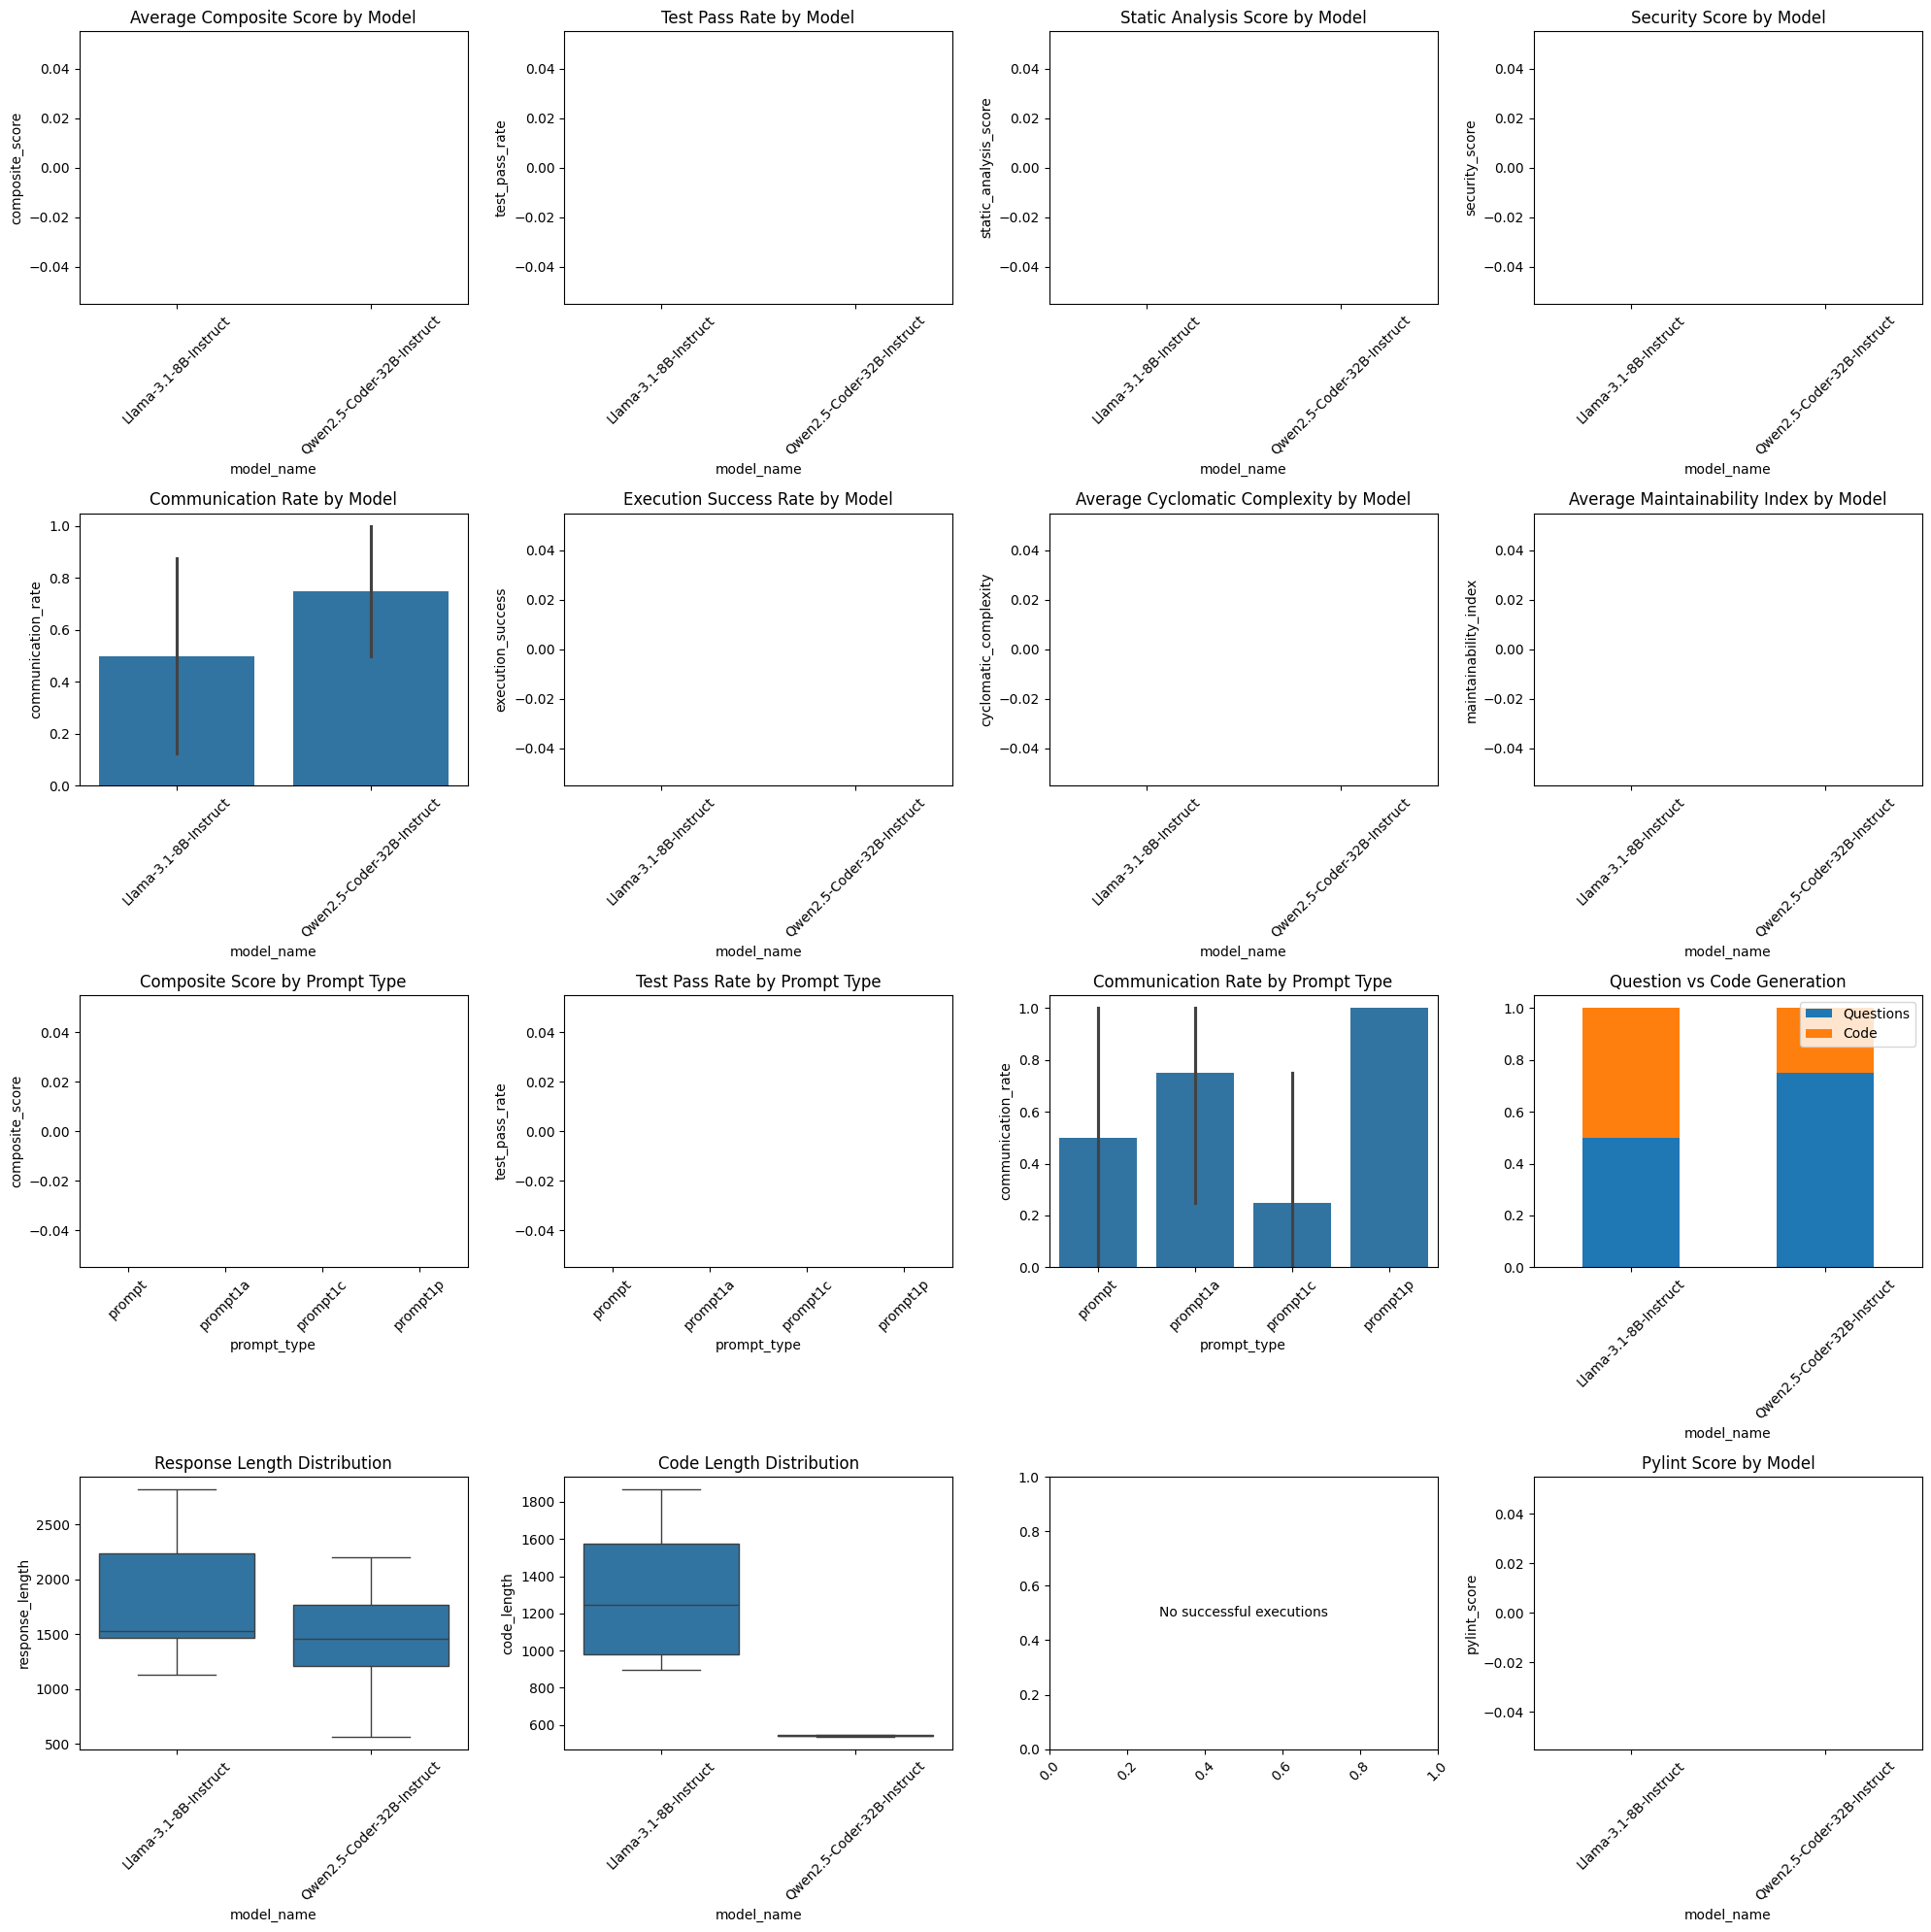

In [42]:
# Visualize results
plt.figure(figsize=(20, 20))

# Plot 1: Composite scores by model
plt.subplot(4, 4, 1)
sns.barplot(data=df, x='model_name', y='composite_score')
plt.title('Average Composite Score by Model')
plt.xticks(rotation=45)

# Plot 2: Test pass rates
plt.subplot(4, 4, 2)
sns.barplot(data=df, x='model_name', y='test_pass_rate')
plt.title('Test Pass Rate by Model')
plt.xticks(rotation=45)

# Plot 3: Static analysis scores
plt.subplot(4, 4, 3)
sns.barplot(data=df, x='model_name', y='static_analysis_score')
plt.title('Static Analysis Score by Model')
plt.xticks(rotation=45)

# Plot 4: Security scores
plt.subplot(4, 4, 4)
sns.barplot(data=df, x='model_name', y='security_score')
plt.title('Security Score by Model')
plt.xticks(rotation=45)

# Plot 5: Communication rates
plt.subplot(4, 4, 5)
sns.barplot(data=df, x='model_name', y='communication_rate')
plt.title('Communication Rate by Model')
plt.xticks(rotation=45)

# Plot 6: Execution success rates
plt.subplot(4, 4, 6)
sns.barplot(data=df, x='model_name', y='execution_success')
plt.title('Execution Success Rate by Model')
plt.xticks(rotation=45)

# Plot 7: Cyclomatic complexity
plt.subplot(4, 4, 7)
sns.barplot(data=df, x='model_name', y='cyclomatic_complexity')
plt.title('Average Cyclomatic Complexity by Model')
plt.xticks(rotation=45)

# Plot 8: Maintainability index
plt.subplot(4, 4, 8)
sns.barplot(data=df, x='model_name', y='maintainability_index')
plt.title('Average Maintainability Index by Model')
plt.xticks(rotation=45)

# Plot 9: Composite scores by prompt type
plt.subplot(4, 4, 9)
sns.barplot(data=df, x='prompt_type', y='composite_score')
plt.title('Composite Score by Prompt Type')
plt.xticks(rotation=45)

# Plot 10: Test pass rates by prompt type
plt.subplot(4, 4, 10)
sns.barplot(data=df, x='prompt_type', y='test_pass_rate')
plt.title('Test Pass Rate by Prompt Type')
plt.xticks(rotation=45)

# Plot 11: Communication by prompt type
plt.subplot(4, 4, 11)
sns.barplot(data=df, x='prompt_type', y='communication_rate')
plt.title('Communication Rate by Prompt Type')
plt.xticks(rotation=45)

# Plot 12: Question vs Code generation
plt.subplot(4, 4, 12)
question_counts = df.groupby('model_name')['is_question'].mean()
code_counts = 1 - question_counts
question_code_df = pd.DataFrame({
    'Questions': question_counts,
    'Code': code_counts
})
question_code_df.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Question vs Code Generation')
plt.xticks(rotation=45)

# Plot 13: Response lengths
plt.subplot(4, 4, 13)
sns.boxplot(data=df, x='model_name', y='response_length')
plt.title('Response Length Distribution')
plt.xticks(rotation=45)

# Plot 14: Code lengths (for successful code generation)
plt.subplot(4, 4, 14)
code_df = df[df['code_length'] > 0]
if not code_df.empty:
    sns.boxplot(data=code_df, x='model_name', y='code_length')
    plt.title('Code Length Distribution')
else:
    plt.text(0.5, 0.5, 'No code generated', ha='center', va='center', transform=plt.gca().transAxes)
plt.xticks(rotation=45)

# Plot 15: Execution time distribution
plt.subplot(4, 4, 15)
success_df = df[df['execution_success'] == True]
if not success_df.empty:
    sns.boxplot(data=success_df, x='model_name', y='execution_time')
    plt.title('Execution Time (Successful Runs)')
else:
    plt.text(0.5, 0.5, 'No successful executions', ha='center', va='center', transform=plt.gca().transAxes)
plt.xticks(rotation=45)

# Plot 16: Pylint scores
plt.subplot(4, 4, 16)
sns.barplot(data=df, x='model_name', y='pylint_score')
plt.title('Pylint Score by Model')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 11. Detailed Results Analysis

Display detailed results and save them for further analysis.

In [43]:
# Display detailed results
print(f"\n📋 Detailed Results (first 10):")
print(df.head(10).to_string(index=False))

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_file = f'benchmark_results_{timestamp}.csv'
df.to_csv(output_file, index=False)
print(f"\n💾 Results saved to: {output_file}")

# Save detailed results as JSON
results_data = []
for result in results:
    results_data.append({
        'problem_id': result.problem_id,
        'model_name': result.model_name,
        'prompt_type': result.prompt_type,
        'is_question': result.is_question,
        'raw_response': result.raw_response,
        'extracted_code': result.extracted_code,
        'composite_score': result.composite_score,
        'test_pass_rate': result.test_pass_rate,
        'static_analysis_score': result.static_analysis_score,
        'security_score': result.security_score,
        'communication_rate': result.communication_rate,
        'question_quality': result.question_quality,
        'execution_success': result.execution_success,
        'execution_time': result.execution_time,
        'memory_usage': result.memory_usage,
        'error_message': result.error_message,
        'timestamp': result.timestamp
    })

json_output_file = f'benchmark_results_{timestamp}.json'
with open(json_output_file, 'w') as f:
    json.dump(results_data, f, indent=2)
print(f"\n💾 Detailed results saved to: {json_output_file}")

print(f"\n🎉 Comprehensive benchmark analysis completed!")


📋 Detailed Results (first 10):
 problem_id                 model_name prompt_type  is_question  communication_rate  question_quality  composite_score  test_pass_rate  static_analysis_score  security_score  execution_success  execution_time  memory_usage  has_error  code_length  response_length  cyclomatic_complexity  maintainability_index  pylint_score  bandit_issues_count
HumanEval/0      Llama-3.1-8B-Instruct      prompt        False                 0.0               0.0              0.0             0.0                    0.0             0.0              False             0.0           0.0       True         1008             1442                    0.0                    0.0           0.0                    0
HumanEval/0      Llama-3.1-8B-Instruct    prompt1a         True                 1.0               0.0              0.0             0.0                    0.0             0.0              False             0.0           0.0      False            0             2749               

## 12. Multi-Dimensional Scoring

Implement the composite scoring formula from the plan.

In [44]:
def calculate_composite_score(correctness: float, communication: float, 
                            readability: float, security: float, 
                            efficiency: float, maintainability: float) -> float:
    """Calculate composite score using the formula from the plan."""
    final_score = (0.40 * correctness +
                  0.20 * communication +
                  0.15 * readability +
                  0.10 * security +
                  0.10 * efficiency +
                  0.05 * maintainability)
    return final_score

# Add composite scores based on the plan's formula
df['plan_composite_score'] = df.apply(
    lambda row: calculate_composite_score(
        row['test_pass_rate'],
        row['communication_rate'],
        row['static_analysis_score'],
        row['security_score'],
        1.0 - (row['execution_time'] / (row['execution_time'] + 1)),  # Efficiency proxy
        row['maintainability_index'] / 100  # Normalize to 0-1
    ), axis=1
)

# Display model comparison with plan-based scoring
print("🏆 Model Performance Summary (Plan-based Scoring):")
plan_summary = df.groupby('model_name').agg({
    'plan_composite_score': 'mean',
    'test_pass_rate': 'mean',
    'communication_rate': 'mean',
    'static_analysis_score': 'mean',
    'security_score': 'mean'
}).round(3)
print(plan_summary)

# Save final results
final_output_file = f'final_benchmark_results_{timestamp}.csv'
df.to_csv(final_output_file, index=False)
print(f"\n💾 Final results saved to: {final_output_file}")

🏆 Model Performance Summary (Plan-based Scoring):
                            plan_composite_score  test_pass_rate  \
model_name                                                         
Llama-3.1-8B-Instruct                       0.20             0.0   
Qwen2.5-Coder-32B-Instruct                  0.25             0.0   

                            communication_rate  static_analysis_score  \
model_name                                                              
Llama-3.1-8B-Instruct                     0.50                    0.0   
Qwen2.5-Coder-32B-Instruct                0.75                    0.0   

                            security_score  
model_name                                  
Llama-3.1-8B-Instruct                  0.0  
Qwen2.5-Coder-32B-Instruct             0.0  

💾 Final results saved to: final_benchmark_results_20250917_004134.csv


## Next Steps and Notes

### What This Notebook Implements:

1. **Dataset Preparation**: Loads HumanEvalComm dataset with multiple prompt variations
2. **Model Inference**: Uses HuggingFace models through OpenAI-compatible API
3. **Communication Metrics**: Measures communication rate and question quality
4. **Code Correctness Metrics**: Evaluates test pass rates and includes fuzzing
5. **Trustworthiness Metrics**: Assesses readability, maintainability, security, and efficiency
6. **Evaluation Reliability**: Uses multi-judge scoring and calibration
7. **Aggregation & Composite Scoring**: Combines metrics using configurable weights
8. **Leaderboard & Reporting**: Generates comprehensive reports and visualizations

### Usage Tips:

1. **API Token**: Make sure your `HF_TOKEN` is set in your .env file
2. **Model Selection**: Modify the `models` dictionary to add/remove models
3. **Problem Count**: Adjust `max_problems` in `load_dataset()` for larger benchmarks
4. **Prompt Types**: Add or remove prompt types from the `prompt_types` list

### Extending the Benchmark:

1. Load more problems by increasing `max_problems`
2. Add more models from the HuggingFace router
3. Include execution time and memory usage analysis
4. Add statistical significance testing between models
5. Implement human calibration for judge scores
6. Add hypothesis-based fuzz testing

Happy benchmarking! 🚀